### [Quantitative Finance: Backtesting Your Portfolio Strategy](https://medium.com/financial-engineering/quantitative-finance-series-backtesting-your-portfolio-strategy-with-python-d4718758c23f)

In [1]:
!pip install -q numpy pandas pandas-datareader matplotlib scipy

##### **Fetching a Longer History of Data**

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.optimize import minimize

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Use the same tickers as the previous article
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM', 'V', 'PG', 'JNJ']

# Fetch a longer history of data for the backtest
start_date = datetime(2010, 1, 1)
end_date = datetime(2024, 12, 31)

# Fetch the 'Adj Close' prices using yfinance
adj_close_df = pd.DataFrame()
for ticker in tickers:
    # Use yf.download to fetch data
    data = yf.download(ticker, start=start_date, end=end_date)
    adj_close_df[ticker] = data['Close']

# Calculate daily log returns
log_returns = np.log(adj_close_df / adj_close_df.shift(1)).dropna()

print("\nData shape: ", log_returns.shape)
log_returns.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Data shape:  (3772, 8)


,AAPL,MSFT,GOOGL,AMZN,JPM,V,PG,JNJ
Date,,,,,,,,
2010-01-05,0.001728,0.000323,-0.004413,0.005883,0.019185,-0.011525,0.000327,-0.011663
2010-01-06,-0.016034,-0.006156,-0.025532,-0.018282,0.005480,-0.013519,-0.004755,0.008101
2010-01-07,-0.001851,-0.010454,-0.023555,-0.017160,0.019615,0.009264,-0.005438,-0.007162
2010-01-08,0.006627,0.006873,0.013243,0.026717,-0.002459,0.002762,-0.001323,0.003431
2010-01-11,-0.008861,-0.012802,-0.001513,-0.024335,-0.003363,-0.002878,-0.003979,0.000156


##### **The Optimization Function**

In [3]:
# We'll assume a constant risk-free rate for simplicity
risk_free_rate = 0.02

def get_optimal_weights(log_returns_slice, bounds_max = 1):
    """
    Finds the optimal portfolio weights for the max Sharpe ratio.
    """
    mean_returns = log_returns_slice.mean()
    cov_matrix = log_returns_slice.cov()
    num_assets = len(tickers)

    def get_portfolio_stats(weights):
        returns = np.sum(mean_returns * weights) * 252
        volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
        return np.array([returns, volatility, (returns - risk_free_rate) / volatility])

    def minimize_negative_sharpe(weights):
        return -get_portfolio_stats(weights)[2]

    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
    bounds = tuple((0, bounds_max) for _ in range(num_assets))
    initial_weights = np.array([1./num_assets] * num_assets)

    result = minimize(minimize_negative_sharpe, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

##### **Setting Up and Running the Backtest Loop**

In [4]:
# Define rebalancing frequency (annually)
annual_rebalance_dates = log_returns.resample('YE').first().index
quarter_rebalance_dates = log_returns.resample('QE').first().index # 'QE' for Quarter-End

# We need at least one year of data to start, so we begin from the second year
backtest_start_date = annual_rebalance_dates[1]

# Store portfolio returns
portfolio_returns = []

# Loop through rebalancing dates
for i in range(len(annual_rebalance_dates) - 1):
    start_period = annual_rebalance_dates[i]
    end_period = annual_rebalance_dates[i+1]

    # 1. Get historical data slice for optimization
    # Ensure we don't include the end_period in the optimization data
    optimization_data = log_returns.loc[:start_period]

    # Define the start of the lookback period
    lookback_start = start_period - pd.DateOffset(years=3)
    optimization_data = log_returns.loc[lookback_start:start_period]

    # 2. Calculate optimal weights for this period
    # Using a try-except block in case optimization fails for a period
    try:
        optimal_weights = get_optimal_weights(optimization_data)
    except:
        # If optimization fails, fall back to equal weights
        optimal_weights = np.array([1./len(tickers)] * len(tickers))

    # 3. Get the returns for the holding period (the next year)
    # Ensure we include the end_period in the holding period data
    holding_period_returns = log_returns.loc[start_period:end_period]

    # 4. Calculate the portfolio's returns for this period
    period_portfolio_return = np.dot(holding_period_returns, optimal_weights)

    # 5. Append the returns to our list as a pandas Series
    # Convert the numpy array to a pandas Series with the correct index
    portfolio_returns.append(pd.Series(period_portfolio_return, index=holding_period_returns.index)) # Convert to Series

# Concatenate all period returns into a single Series
backtest_returns = pd.concat(portfolio_returns)
backtest_returns.name = "MPT Strategy"

##### **Creating a Benchmark**

In [5]:
# Create benchmark returns (equal weight)
num_tickers = len(tickers)
equal_weights = np.array([1/num_tickers] * num_tickers)
benchmark_returns = log_returns.dot(equal_weights)
benchmark_returns = benchmark_returns.loc[backtest_returns.index] # Align dates
benchmark_returns.name = "Equal Weight Benchmark"

##### **Analyzing and Visualizing the Performance**

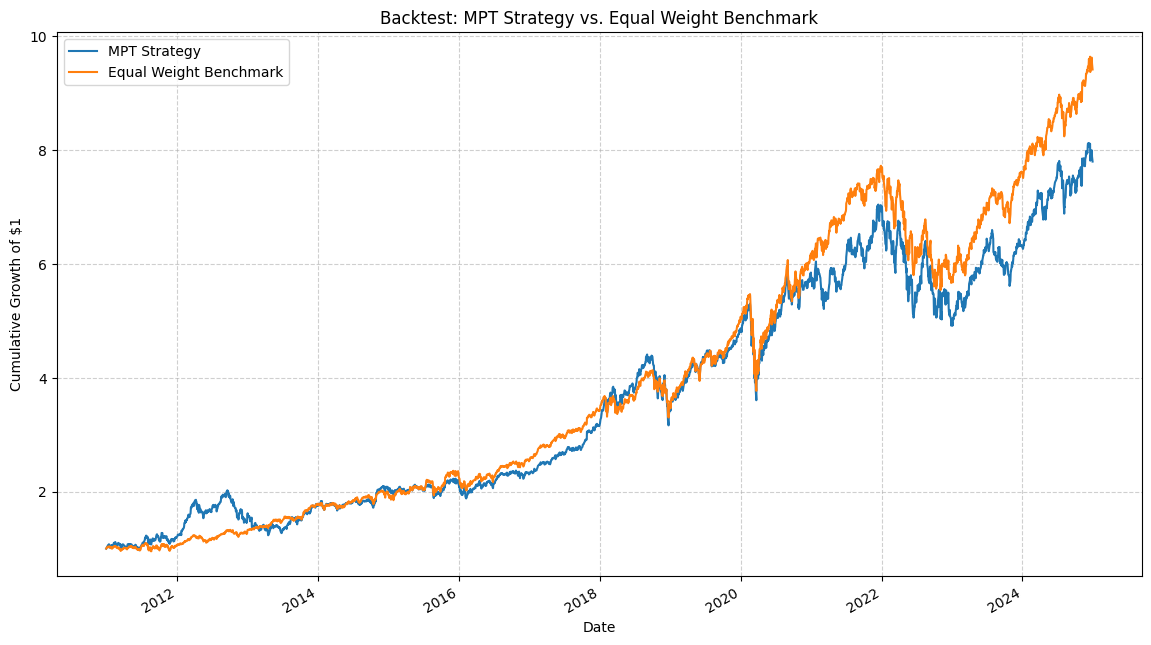

In [6]:
# Calculate cumulative returns
cumulative_mpt_returns = (1 + backtest_returns).cumprod()
cumulative_benchmark_returns = (1 + benchmark_returns).cumprod()

# Plot the results
plt.figure(figsize=(14, 8))
cumulative_mpt_returns.plot(label=backtest_returns.name, legend=True)
cumulative_benchmark_returns.plot(label=benchmark_returns.name, legend=True)
plt.title('Backtest: MPT Strategy vs. Equal Weight Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### **Calculating Performance Metrics**

In [7]:
def calculate_performance_metrics(returns):
    """Calculates key performance metrics for a series of returns."""
    total_return = (1 + returns).prod() - 1
    num_years = len(returns) / 252
    annualized_return = (1 + total_return) ** (1/num_years) - 1
    annualized_volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility

    # Calculate Maximum Drawdown
    cumulative_returns = (1 + returns).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns/peak) - 1
    max_drawdown = drawdown.min()

    metrics = {
        'Cumulative Return': f"{total_return:.2%}",
        'Annualized Return (CAGR)': f"{annualized_return:.2%}",
        'Annualized Volatility': f"{annualized_volatility:.2%}",
        'Sharpe Ratio': f"{sharpe_ratio:.2f}",
        'Maximum Drawdown': f"{max_drawdown:.2%}"
    }
    return pd.Series(metrics)

# Calculate and display metrics for both strategies
mpt_metrics = calculate_performance_metrics(backtest_returns)
benchmark_metrics = calculate_performance_metrics(benchmark_returns)

results_df = pd.DataFrame({
    'MPT Strategy': mpt_metrics,
    'Equal Weight Benchmark': benchmark_metrics
})

print("\n--- Backtest Performance Metrics ---")
display(results_df)


--- Backtest Performance Metrics ---


,MPT Strategy,Equal Weight Benchmark
Cumulative Return,679.91%,841.75%
Annualized Return (CAGR),15.79%,17.36%
Annualized Volatility,22.33%,18.01%
Sharpe Ratio,0.62,0.85
Maximum Drawdown,-38.98%,-31.09%


##### **Refine the Lookback Window for Optimization**

In [ ]:
# Define the start of the lookback period
lookback_start = start_period - pd.DateOffset(years=3)
optimization_data = log_returns.loc[lookback_start:start_period]

###### **Modify the Optimization Constraints**

In [ ]:
bounds = tuple((0, 0.30) for _ in range(num_assets)) ## get_optimal_weights

##### **Use a Dynamic Risk-Free Rate**

In [ ]:
# get_optimal_weights

# Add this after fetching stock data
rf_data = yf.download('^IRX', start=start_date, end=end_date)
risk_free_rates = (rf_data['Close'] / 100).resample('YE').last() # Get year-end rates

# Modify the function call in the loop
# ...
current_risk_free_rate = risk_free_rates.loc[start_period]
optimal_weights = get_optimal_weights(optimization_data, current_risk_free_rate)
#...